# How good is it with one, two or three agents locked in?

Notebooks 13 to 15 measured the recommender at the two ends only: **four agents locked in**
(name the fifth) and **none** (build all five from the map). The app is used in between as
well — lock in one agent, or two, and ask for the rest — and that middle had no number on it.

**Added on 2026-09-22, after both tests had run**, to answer that question. So:

- **It uses the development data only** — the same as notebook 13: learning from all of 2024,
  scored week by week on 2025 up to Masters Toronto. Neither test set (the second half of
  2025, and 2026) is touched. Both have been used once and stay that way.
- **It changes nothing.** The methods and their recency settings are notebook 13's, as they
  were. Nothing here is used to choose or tune anything; it describes the methods already
  chosen.

## The questions, set before running

Every development line-up is asked every way it can be: with each possible set of 0, 1, 2, 3
and 4 of its own agents locked in (1 + 5 + 10 + 10 + 5 = 31 questions per line-up). Each time,
the method fills the rest one pick at a time, exactly as `build_from_scratch` does — its best
agent, then its best given that one, and so on.

Two measures, for each number locked in:

1. **Next pick right** — its first suggestion is one of the agents the pros actually played
   alongside the locked ones.
2. **Rest right** — of the agents it fills in, the share the pros actually played.

With four locked in both are the same thing, and equal notebook 13's top-1. With none locked
in, "rest right" is notebook 13's from-scratch figure divided by five. **Both are checked
below**; if either fails to match, the scoring here is wrong.

A caution on reading it. With fewer agents locked in, *more* answers count as right (with one
locked, any of the other four will do), so the percentages are not a difficulty scale. The
comparison that means something is **each method against the naive rule at the same number
locked in**.

**Methods**, each at the half-life notebook 13 found best for it: the naive rule (7 days),
co-occurrence (21), the classifier (45), the classifier with map × agent columns (21), and
gradient boosting (45, the headline).

In [1]:
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))

pd.set_option("display.width", 200)

from sklearn.ensemble import HistGradientBoostingClassifier

from dataset import build_map_table, split_season
from recommend import Classifier, CoOccurrence, Popularity, lineup_table

INK, MUTED, RULE = "#2A3038", "#5A6570", "#D5DAE0"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": RULE, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RULE, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})

## 1. The line-ups — the same as notebook 13

In [2]:
history = lineup_table(build_map_table("vct_2024"))
learn_2025, _ = split_season(build_map_table())       # the test half is not used here
dev = lineup_table(learn_2025)

print(f"learned from : {len(history):,} line-ups, all of 2024")
print(f"scored on    : {len(dev):,} line-ups, 2025 up to Masters Toronto, "
      f"{dev.played_at.dt.to_period('W').nunique()} weeks")
print(f"               x 31 ways of locking = {len(dev) * 31:,} questions per method")

learned from : 2,208 line-ups, all of 2024
scored on    : 1,512 line-ups, 2025 up to Masters Toronto, 20 weeks
               x 31 ways of locking = 46,872 questions per method


## 2. The scoring

`complete` fills a line-up the way `build_from_scratch` in `src/recommend.py` does, but
starting from the locked agents. Answers are remembered within a week — the same map with the
same agents locked comes up many times, and the model is the same all week, so this only saves
time; it cannot change an answer.

In [3]:
def complete(model, map_name, locked, memo):
    """The method's picks for the rest of the line-up, one at a time."""
    picked = list(locked)
    for _ in range(5 - len(locked)):
        key = (map_name, frozenset(picked))
        if key not in memo:
            memo[key] = model.scores(map_name, picked).drop(picked, errors="ignore").idxmax()
        picked.append(memo[key])
    return picked[len(locked):]


def walk_forward_partial(history, to_score, make_model):
    """Every way of locking 0-4 agents of every line-up, each week using only earlier weeks."""
    everything = pd.concat([history, to_score], ignore_index=True)
    week_start = to_score["played_at"].dt.to_period("W").dt.start_time
    rows = []
    for start in sorted(week_start.unique()):
        model = make_model().fit(everything[everything["played_at"] < start], as_of=start)
        memo = {}
        for idx in to_score.index[week_start == start]:
            lineup, map_name = to_score.at[idx, "agents"], to_score.at[idx, "map"]
            for k in range(5):
                for locked in combinations(lineup, k):
                    suggested = complete(model, map_name, locked, memo)
                    rest = set(lineup) - set(locked)
                    rows.append({"row": idx, "match_id": to_score.at[idx, "match_id"], "locked": k,
                                 "next_right": suggested[0] in rest,
                                 "rest_right": len(set(suggested) & rest) / (5 - k)})
    return pd.DataFrame(rows)

## 3. Every method, every number locked in

This takes about an hour, almost all of it gradient boosting.

In [4]:
METHODS = {
    "naive rule": lambda: Popularity(7),
    "co-occurrence": lambda: CoOccurrence(21),
    "classifier": lambda: Classifier(45),
    "classifier + map x agent": lambda: Classifier(21, interactions=True),
    "gradient boosting": lambda: Classifier(45, estimator=HistGradientBoostingClassifier(random_state=0)),
}
runs = {name: walk_forward_partial(history, dev, make) for name, make in METHODS.items()}

### Checking against notebook 13

Notebook 13's figures, written in here by hand: top-1 with four locked, and from-scratch
agents out of five.

In [5]:
NOTEBOOK_13 = {   # (top-1 with four locked, from scratch of 5), as printed there
    "naive rule": (0.489, 3.26), "co-occurrence": (0.692, 3.17), "classifier": (0.656, 3.12),
    "classifier + map x agent": (0.685, 3.11), "gradient boosting": (0.682, 3.11),
}
for name, r in runs.items():
    four = r.loc[r.locked == 4, "next_right"].mean()
    scratch = r.loc[r.locked == 0, "rest_right"].mean() * 5
    top1, fs = NOTEBOOK_13[name]
    ok = round(four, 3) == top1 and round(scratch, 2) == fs
    print(f"{name:26} four locked {four:.1%} (nb13 {top1:.1%})   from scratch {scratch:.2f} (nb13 {fs:.2f})"
          f"   {'matches' if ok else 'DIFFERS'}")

naive rule                 four locked 48.9% (nb13 48.9%)   from scratch 3.26 (nb13 3.26)   matches
co-occurrence              four locked 69.2% (nb13 69.2%)   from scratch 3.17 (nb13 3.17)   matches
classifier                 four locked 65.6% (nb13 65.6%)   from scratch 3.12 (nb13 3.12)   matches
classifier + map x agent   four locked 68.5% (nb13 68.5%)   from scratch 3.11 (nb13 3.11)   matches
gradient boosting          four locked 68.2% (nb13 68.2%)   from scratch 3.11 (nb13 3.11)   matches


## 4. The results

In [6]:
def table(measure):
    t = pd.DataFrame({name: r.groupby("locked")[measure].mean() for name, r in runs.items()})
    t.index.name = "agents locked in"
    return t

print("NEXT PICK RIGHT -- its first suggestion is one the pros played\n")
print(table("next_right").map("{:.1%}".format).to_string())
print("\n\nREST RIGHT -- share of the agents it fills in that the pros played\n")
print(table("rest_right").map("{:.1%}".format).to_string())

NEXT PICK RIGHT -- its first suggestion is one the pros played

                 naive rule co-occurrence classifier classifier + map x agent gradient boosting
agents locked in                                                                               
0                     90.7%         91.4%      91.2%                    90.3%             89.2%
1                     86.3%         88.3%      85.6%                    86.6%             85.7%
2                     79.8%         84.9%      82.5%                    82.6%             81.1%
3                     69.0%         79.6%      77.1%                    77.8%             76.5%
4                     48.9%         69.2%      65.6%                    68.5%             68.2%


REST RIGHT -- share of the agents it fills in that the pros played

                 naive rule co-occurrence classifier classifier + map x agent gradient boosting
agents locked in                                                                               
0 

### Gradient boosting against the naive rule, at each number locked in

Resampling whole matches, as in notebooks 13 to 15. Both methods answer the same questions,
so the comparison is paired.

In [7]:
gb, naive = runs["gradient boosting"], runs["naive rule"]
assert (gb[["row", "locked"]].to_numpy() == naive[["row", "locked"]].to_numpy()).all()

match_ids = gb["match_id"].unique()
rng = np.random.default_rng(0)
draws = [rng.choice(match_ids, len(match_ids)) for _ in range(3000)]

print("gradient boosting minus the naive rule, in points (95% range):\n")
for k in range(5):
    part = gb.locked == k
    for measure in ["next_right", "rest_right"]:
        diff = (gb.loc[part, measure].astype(float) - naive.loc[part, measure].astype(float))
        by_match = diff.groupby(gb.loc[part, "match_id"]).agg(["sum", "count"])
        sums, counts = by_match["sum"], by_match["count"]
        boot = [sums.reindex(d).sum() / counts.reindex(d).sum() * 100 for d in draws]
        lo, hi = np.percentile(boot, [2.5, 97.5])
        print(f"   {k} locked   {measure:10}  {diff.mean() * 100:+5.1f}   ({lo:+.1f} to {hi:+.1f})")

gradient boosting minus the naive rule, in points (95% range):



   0 locked   next_right   -1.6   (-3.1 to -0.1)


   0 locked   rest_right   -3.0   (-3.9 to -2.1)


   1 locked   next_right   -0.7   (-1.8 to +0.5)


   1 locked   rest_right   +1.4   (+0.6 to +2.3)


...

   2 locked   rest_right   +6.7   (+5.7 to +7.8)


   3 locked   next_right   +7.5   (+6.0 to +9.0)


   3 locked   rest_right  +12.8   (+11.5 to +14.1)


   4 locked   next_right  +19.3   (+17.6 to +21.0)


   4 locked   rest_right  +19.3   (+17.6 to +21.0)


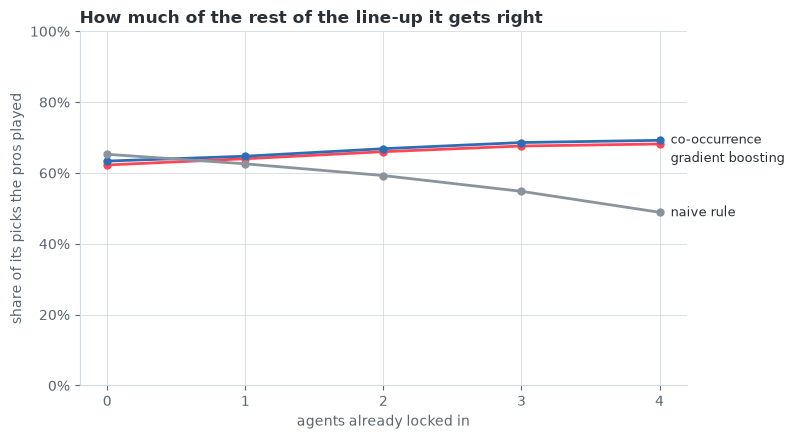

In [8]:
rest = table("rest_right")
colours = {"gradient boosting": "#FF4655", "co-occurrence": "#2E6DB4", "naive rule": "#8A949E"}
fig, ax = plt.subplots(figsize=(9, 4.6))
ends = []
for name, colour in colours.items():
    ax.plot(rest.index, rest[name], color=colour, lw=2, marker="o", ms=5)
    ends.append([rest[name].iloc[-1], name])
ends.sort(reverse=True)                      # top to bottom, then push apart any that crowd
for i in range(1, len(ends)):
    ends[i][0] = min(ends[i][0], ends[i - 1][0] - 0.05)
for y, name in ends:
    ax.annotate(name, (rest.index[-1], y), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
ax.set_xticks(range(5))
ax.set_xlabel("agents already locked in")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylabel("share of its picks the pros played")
ax.set_title("How much of the rest of the line-up it gets right", loc="left")
fig.subplots_adjust(right=0.8)
plt.show()

## What this means

*Written after the cells above were run. Development data only; neither test set was touched.*

**The scoring is right:** with four locked in and with none, every method matches notebook 13
exactly.

**Gradient boosting against the naive rule, on the share of the rest of the line-up it gets
right:**

| Agents locked in | Gradient boosting | Naive rule | Difference (95% range) |
|---|---|---|---|
| 0 | 62.3% | **65.3%** | −3.0 (−3.9 to −2.1) |
| 1 | 64.0% | 62.6% | +1.4 (+0.6 to +2.3) |
| 2 | 66.0% | 59.3% | +6.7 (+5.7 to +7.8) |
| 3 | 67.6% | 54.8% | +12.8 (+11.5 to +14.1) |
| 4 | 68.2% | 48.9% | +19.3 (+17.6 to +21.0) |

1. **The more agents are locked in, the bigger the recommender's lead.** The naive rule ignores
   the locked agents, so it gets worse as more are locked; the recommender uses them, and gets
   slightly better. Each locked agent is information only the recommender can use.
2. **With nothing locked in, the naive rule is best** — the from-scratch result of notebooks 13
   to 15, seen again. This is why the app shows the pros' most common line-ups, not the
   model's, when nothing is locked in.
3. **With one agent locked in, it is only just ahead**: +1.4 points on the rest of the
   line-up, and level on the very next pick (−0.7, range −1.8 to +0.5). The app hands over to
   the recommender at one locked agent; that is justified — never worse, slightly better —
   but the real value starts at two.
4. **Co-occurrence is marginally the best at one to three locked** — it and the classifier
   with map × agent columns were also the best at naming the pick first in notebooks 13 to 15. Gradient boosting stays the headline, by the rule set
   before any result; the gaps are about a point.

**How to quote it.** These are development figures, from the same weeks the methods were
chosen on, so they are a description, not a test. The tests measured four locked in only, on
top-3, and there the lead over the naive rule came in a few points below development (+14.0
and +15.3 points, against +16.9). Expect the middle of this table to shrink a little the same
way on new data. The 68.2% with four locked is the "named first" figure; the headline 88–91% is "in the
top three", so they do not conflict.